In [32]:
# === setup ===
import numpy as np
import tensorflow as tf
import torch
import matplotlib.pyplot as plt
from utils.data_utils.load_data import extract_target_properties
from utils.evaluate_utils.load_models import load_fNN_model
from plot_elastic_surface import plot_elastic_surface

# === load Max's forward model ===
fNN = load_fNN_model()

# === load normalization constants (adjust path if needed) ===
THETA_PATTERN = "001"
P_mean_path = f"data/partition_by_theta/P_mean_theta_{THETA_PATTERN}.npy"
P_std_path = f"data/partition_by_theta/P_std_theta_{THETA_PATTERN}.npy"
P_mean = np.load(P_mean_path)
P_std = np.load(P_std_path)
print(f"✅ Loaded normalization constants for THETA_PATTERN = {THETA_PATTERN}")

# === define your custom structure vector(s) S ===
# format: [[theta_1, theta_2, theta_3, rho]], shape = (N, 4)
S_custom = np.array([
    [0.00000, 0.00000, 21.85420, 0.52015],	# S_true
    [0.00000, 0.00000, 15.00000, 0.59588]   # S_hat
])

# === pretty print full precision for S_custom ===
np.set_printoptions(suppress=False)  # don't suppress scientific notation

print(f"✅ Loaded S-true and S-hat:")
print(f"        - S-true: {np.array2string(S_custom[0], formatter={'float_kind':lambda x: f'{x:.5f}'})}")
print(f"        - S-hat : {np.array2string(S_custom[1], formatter={'float_kind':lambda x: f'{x:.5f}'})}")


✅ Loaded Max's forward model
✅ Loaded normalization constants for THETA_PATTERN = 001
✅ Loaded S-true and S-hat:
        - S-true: [0.00000 0.00000 21.85420 0.52015]
        - S-hat : [0.00000 0.00000 15.00000 0.59588]


In [33]:
# === forward evaluation ===
def evaluate_forward_model(S_batch, fNN, P_mean, P_std):
    """
    Evaluate Max's forward model on a batch of structure vectors.

    Args:
        S_batch (np.ndarray): shape (N, 4)
        fNN: loaded TensorFlow forward model
        P_mean, P_std: normalization constants (1D arrays of shape (9,))

    Returns:
        P_pred: unnormalized elastic property predictions, shape (N, 9)
        C_pred: full fourth-order tensors, shape (N, 3, 3, 3, 3)
    """
    S_tensor = tf.convert_to_tensor(S_batch.reshape(-1, 1, 4), dtype=tf.float32)

    # run model and remove dummy dimensions
    C_pred = fNN(S_tensor).numpy()
    while C_pred.ndim > 5:
        C_pred = np.squeeze(C_pred, axis=1)  # squeeze extra dimensions

    if C_pred.shape[-4:] != (3, 3, 3, 3):
        raise ValueError(f"Unexpected output shape from fNN: {C_pred.shape}")

    # extract and denormalize
    P_pred_norm = extract_target_properties(C_pred)  # shape (N, 9)
    P_pred_unnorm = P_pred_norm * P_std + P_mean
    return P_pred_unnorm, C_pred

# === component labels for display ===
component_labels = [
    "C1111", "C1122", "C1133",
    "C2222", "C2233", "C3333",
    "C1212", "C1313", "C2323"
]

# === evaluate and print results ===
P_pred, C_pred = evaluate_forward_model(S_custom, fNN, P_mean, P_std)

for i, (S, P) in enumerate(zip(S_custom, P_pred)):
    print(f"\n✅ Structure {i+1}: S = {np.array2string(S, formatter={'float_kind':lambda x: f'{x}'})}")
    print("   Predicted Properties (P):")
    for label, val in zip(component_labels, P):
        print(f"   {label}: {val:.4f}")


✅ Structure 1: S = [0.0 0.0 21.8542 0.52015]
   Predicted Properties (P):
   C1111: 0.7739
   C1122: 0.2414
   C1133: 0.1898
   C2222: 0.7739
   C2233: 0.1898
   C3333: 0.4475
   C1212: 0.3295
   C1313: 0.3015
   C2323: 0.3945

✅ Structure 2: S = [0.0 0.0 15.0 0.59588]
   Predicted Properties (P):
   C1111: 0.8235
   C1122: 0.2483
   C1133: 0.1908
   C2222: 0.8236
   C2233: 0.1908
   C3333: 0.4624
   C1212: 0.3401
   C1313: 0.3022
   C2323: 0.3952


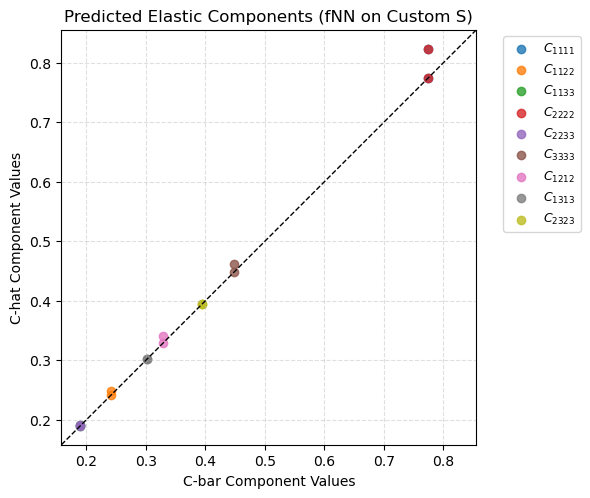

In [ ]:
# === plot predicted P components ===
def plot_predicted_Ps(P_pred, component_labels=None):
    """
    Plots a scatter plot of predicted elastic components for each S input.

    Args:
        P_pred (np.ndarray): shape (N, 9), unnormalized predictions from fNN
        component_labels (list of str): Optional LaTeX-style labels for 9 components
    """
    if component_labels is None:
        component_labels = [r"$C_{1111}$", r"$C_{1122}$", r"$C_{1133}$",
                            r"$C_{2222}$", r"$C_{2233}$", r"$C_{3333}$",
                            r"$C_{1212}$", r"$C_{1313}$", r"$C_{2323}$"]

    P_pred = np.array(P_pred)
    fig, ax = plt.subplots(figsize=(6, 6))  # square figure

    for i in range(P_pred.shape[1]):
        x_vals = [P_pred[0, i]] * len(P_pred)
        y_vals = P_pred[:, i]
        ax.scatter(x_vals, y_vals, label=component_labels[i], alpha=0.8)

    # diagonal y = x line
    all_vals = P_pred.flatten()
    min_val, max_val = all_vals.min(), all_vals.max()
    buffer = (max_val - min_val) * 0.05
    ax.plot([min_val - buffer, max_val + buffer],
            [min_val - buffer, max_val + buffer],
            'k--', linewidth=1)

    ax.set_xlim(min_val - buffer, max_val + buffer)
    ax.set_ylim(min_val - buffer, max_val + buffer)
    ax.set_aspect('equal', adjustable='box')  # force square axes

    ax.set_xlabel("C-bar Component Values")
    ax.set_ylabel("C-hat Component Values")
    ax.set_title("Predicted Elastic Components (fNN on Custom S)")
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

# === usage ===
plot_predicted_Ps(P_pred)


✅ Plotting elastic surface for S_true...


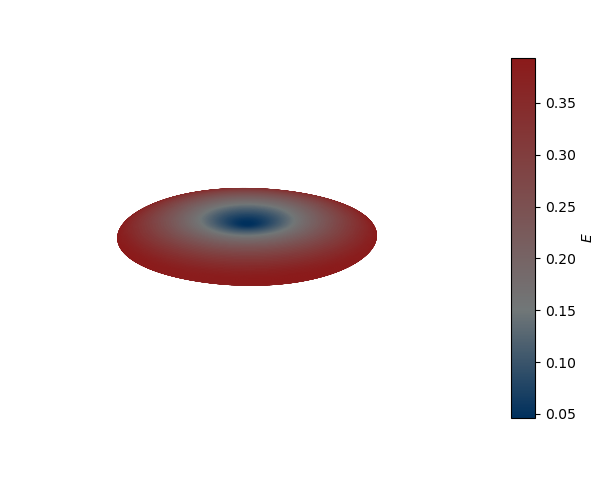


✅ Plotting elastic surface for S_hat...


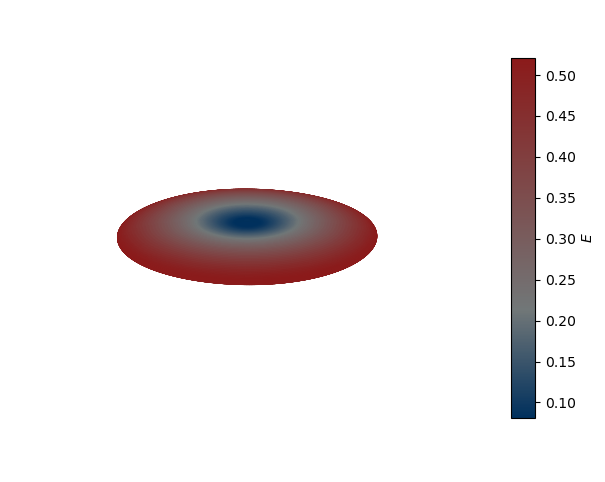

In [31]:
# === elastic surface plots ===
print("\n✅ Plotting elastic surface for S_true...")
plot_elastic_surface(C_pred[0])

print("\n✅ Plotting elastic surface for S_hat...")
plot_elastic_surface(C_pred[1])